# 📊 Phân tích Giá Xăng Việt Nam 2021–2025
### Dữ liệu: RON 95-III | Chu kỳ điều chỉnh: Thứ Năm hàng tuần (Nghị định 80/2023/NĐ-CP)

**5 câu hỏi phân tích:**
1. Giai đoạn nào giá xăng tăng / giảm liên tục trong 5 năm?
2. 3 tháng có mức biến động cao nhất là tháng nào?
3. Năm nào có giá trung bình cao nhất?
4. Tháng nào có giá thấp nhất trong 5 năm?
5. Xu hướng tổng thể theo từng năm thay đổi như thế nào?


## 1. Import thư viện & Tải dữ liệu

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# Cài đặt font hiển thị tiếng Việt tốt hơn
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# ── Đọc dữ liệu ──
df_raw = pd.read_csv('giaxang.csv')
df_raw.columns = ['Ngay', 'RON95', 'E5RON92', 'DO', 'KO']
df_raw['Ngay'] = pd.to_datetime(df_raw['Ngay'], dayfirst=True)

# ── Lọc 2021–2025 ──
df = df_raw[df_raw['Ngay'].dt.year.between(2021, 2025)].copy()
df = df.reset_index(drop=True)

# ── Đổi đơn vị: ×1000 để ra VNĐ/lít ──
for col in ['RON95', 'E5RON92', 'DO', 'KO']:
    df[col] = (df[col] * 1000).round(0).astype(int)

# ── Thêm cột phụ trợ ──
df['Nam']   = df['Ngay'].dt.year
df['Thang'] = df['Ngay'].dt.month
df['Thang_Nam'] = df['Ngay'].dt.to_period('M')

print(f"Tổng số kỳ điều chỉnh (2021–2025): {len(df)}")
print(f"Phạm vi: {df['Ngay'].min().date()} → {df['Ngay'].max().date()}")
print()
df[['Ngay','RON95','E5RON92','DO','KO']].head(10)


Tổng số kỳ điều chỉnh (2021–2025): 198
Phạm vi: 2021-01-11 → 2025-12-25



,Ngay,RON95,E5RON92,DO,KO
0,2021-01-11,16930,15940,12640,11550
1,2021-01-26,17270,16300,13040,11900
2,2021-02-10,17270,16300,13040,11900
3,2021-02-25,18080,17030,13840,12610
4,2021-03-12,18880,17720,14400,13170
5,2021-03-27,19040,17850,14240,13000
6,2021-04-12,18970,17800,14140,12820
7,2021-04-27,19160,17980,14320,13250
8,2021-05-12,19530,18420,14770,13820
9,2021-05-27,19530,18420,14770,13820


## 2. Tổng quan dữ liệu

In [4]:
# Thống kê mô tả RON 95
stats = df[['RON95']].describe().astype(int)
stats.index = ['Số kỳ', 'TB (₫)', 'SD (₫)', 'Min (₫)', 'Q1 (₫)', 'Median (₫)', 'Q3 (₫)', 'Max (₫)']
print("=== Thống kê RON 95-III (2021–2025) ===")
print(stats.to_string())
print()
print(f"Giá cao nhất : {df['RON95'].max():,}₫  ({df.loc[df['RON95'].idxmax(),'Ngay'].date()})")
print(f"Giá thấp nhất: {df['RON95'].min():,}₫  ({df.loc[df['RON95'].idxmin(),'Ngay'].date()})")
print(f"Biên độ dao động: {df['RON95'].max()-df['RON95'].min():,}₫")


=== Thống kê RON 95-III (2021–2025) ===
            RON95
Số kỳ         198
TB (₫)      22397
SD (₫)       2805
Min (₫)     16930
Q1 (₫)      20485
Median (₫)  21935
Q3 (₫)      23620
Max (₫)     32870

Giá cao nhất : 32,870₫  (2022-06-21)
Giá thấp nhất: 16,930₫  (2021-01-11)
Biên độ dao động: 15,940₫


## 3. Biểu đồ xu hướng giá RON 95 (2021–2025)

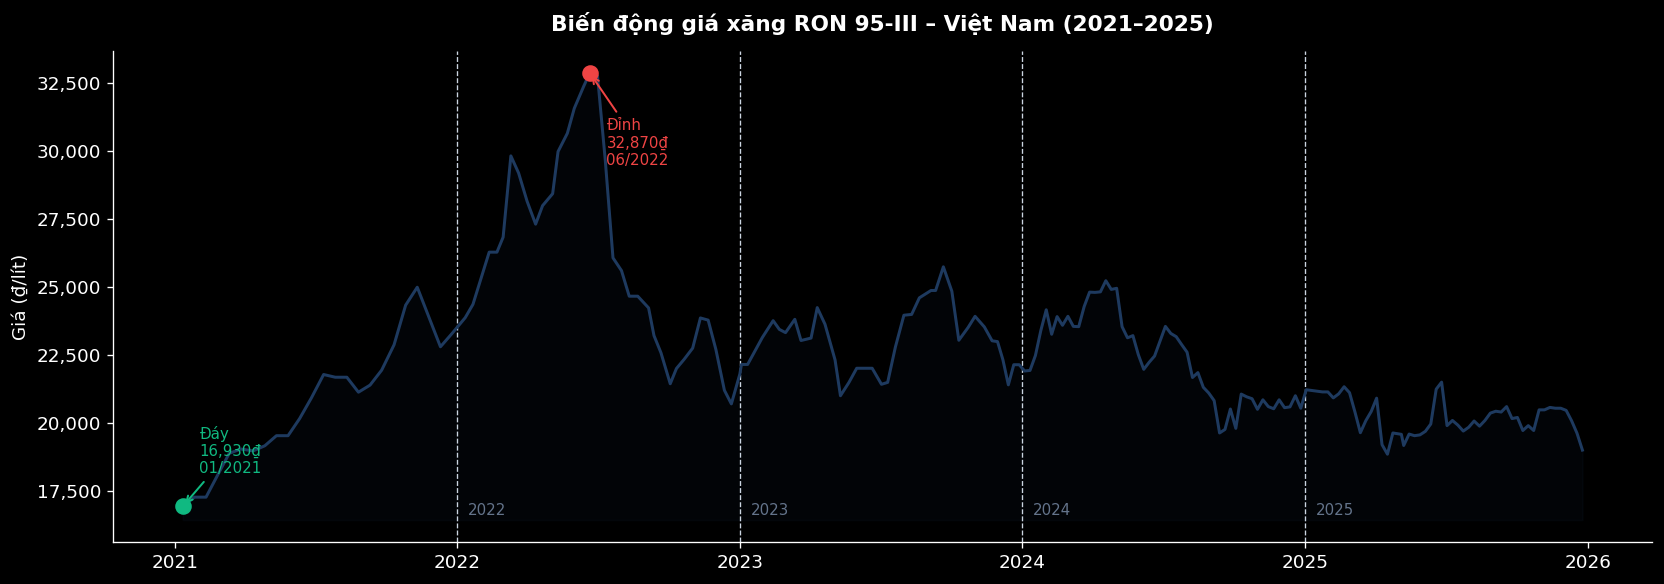

In [5]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df['Ngay'], df['RON95'], color='#1E3A5F', linewidth=1.8, zorder=3)
ax.fill_between(df['Ngay'], df['RON95'], df['RON95'].min() - 500,
                alpha=0.08, color='#1E3A5F')

# Đỉnh & đáy
idx_max = df['RON95'].idxmax()
idx_min = df['RON95'].idxmin()

ax.scatter(df.loc[idx_max,'Ngay'], df.loc[idx_max,'RON95'],
           color='#EF4444', s=80, zorder=5)
ax.annotate(f"Đỉnh\n{df.loc[idx_max,'RON95']:,}₫\n{df.loc[idx_max,'Ngay'].strftime('%m/%Y')}",
            xy=(df.loc[idx_max,'Ngay'], df.loc[idx_max,'RON95']),
            xytext=(10, -55), textcoords='offset points',
            fontsize=9, color='#EF4444',
            arrowprops=dict(arrowstyle='->', color='#EF4444', lw=1.2))

ax.scatter(df.loc[idx_min,'Ngay'], df.loc[idx_min,'RON95'],
           color='#10B981', s=80, zorder=5)
ax.annotate(f"Đáy\n{df.loc[idx_min,'RON95']:,}₫\n{df.loc[idx_min,'Ngay'].strftime('%m/%Y')}",
            xy=(df.loc[idx_min,'Ngay'], df.loc[idx_min,'RON95']),
            xytext=(10, 20), textcoords='offset points',
            fontsize=9, color='#10B981',
            arrowprops=dict(arrowstyle='->', color='#10B981', lw=1.2))

# Phân cách năm
for year in range(2022, 2026):
    ax.axvline(pd.Timestamp(f'{year}-01-01'), color='#CBD5E1', linewidth=0.8, linestyle='--')
    ax.text(pd.Timestamp(f'{year}-01-15'), df['RON95'].min() - 300,
            str(year), fontsize=9, color='#64748B')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax.set_title('Biến động giá xăng RON 95-III – Việt Nam (2021–2025)', fontweight='bold', pad=12)
ax.set_ylabel('Giá (₫/lít)')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig('bieu_do_xu_huong.png', bbox_inches='tight')
plt.show()


## 4. Phân tích chuỗi tăng / giảm liên tiếp (Câu hỏi 1)

**Thuật toán:**
- Bước 1: Tính `diff()` – chênh lệch giá giữa 2 kỳ liên tiếp
- Bước 2: Tạo cột nhị phân `Tang`: `1` nếu giá tăng, `0` nếu giảm/giữ nguyên
- Bước 3: Xử lý nhiễu – nếu đang trong chuỗi tăng mà gặp 1 kỳ giảm **< 500₫**, vẫn coi là tiếp tục tăng
- Bước 4: Đếm độ dài từng chuỗi liên tiếp (streak) → tìm giai đoạn dài nhất


In [6]:
# ── Bước 1 & 2: Diff + cột nhị phân cơ bản ──────────────────────
df['Diff'] = df['RON95'].diff()
df['Tang'] = (df['Diff'] > 0).astype(int)

print("=== Chuỗi nhị phân Tang (10 kỳ đầu) ===")
print(df[['Ngay','RON95','Diff','Tang']].head(10).to_string(index=False))


=== Chuỗi nhị phân Tang (10 kỳ đầu) ===
      Ngay  RON95  Diff  Tang
2021-01-11  16930   NaN     0
2021-01-26  17270 340.0     1
2021-02-10  17270   0.0     0
2021-02-25  18080 810.0     1
2021-03-12  18880 800.0     1
2021-03-27  19040 160.0     1
2021-04-12  18970 -70.0     0
2021-04-27  19160 190.0     1
2021-05-12  19530 370.0     1
2021-05-27  19530   0.0     0


In [7]:
# ── Bước 3: Xử lý nhiễu – ngưỡng 500₫ ──────────────────────────
NOISE_THRESHOLD = 500  # VNĐ

tang_smooth = df['Tang'].copy()

for i in range(1, len(df) - 1):
    if tang_smooth.iloc[i] == 0:
        drop = abs(df['Diff'].iloc[i])   # độ giảm kỳ này
        prev_up = tang_smooth.iloc[i-1] == 1
        next_up = df['Diff'].iloc[i+1] > 0 if i+1 < len(df) else False
        # Nếu: đang tăng + giảm nhẹ + kỳ sau tăng lại → bỏ qua nhiễu
        if prev_up and drop < NOISE_THRESHOLD and next_up:
            tang_smooth.iloc[i] = 1

df['Tang_smooth'] = tang_smooth

noise_count = (df['Tang'] != df['Tang_smooth']).sum()
print(f"Số kỳ được xử lý nhiễu (bỏ qua giảm < {NOISE_THRESHOLD:,}₫): {noise_count} kỳ")


Số kỳ được xử lý nhiễu (bỏ qua giảm < 500₫): 18 kỳ


In [8]:
# ── Bước 4: Đếm streak ──────────────────────────────────────────
def dem_streak(series_bin, df_ref):
    """
    Từ chuỗi nhị phân 0/1, tìm tất cả các đoạn liên tiếp.
    Trả về DataFrame: start_idx, end_idx, huong, do_dai, ngay_bat_dau, ngay_ket_thuc
    """
    streaks = []
    i = 0
    arr = series_bin.values
    while i < len(arr):
        j = i
        val = arr[i]
        while j < len(arr) and arr[j] == val:
            j += 1
        streaks.append({
            'start_idx'     : i,
            'end_idx'       : j - 1,
            'huong'         : 'TANG' if val == 1 else 'GIAM/FLAT',
            'do_dai'        : j - i,
            'ngay_bat_dau'  : df_ref.iloc[i]['Ngay'],
            'ngay_ket_thuc' : df_ref.iloc[j-1]['Ngay'],
            'gia_bat_dau'   : df_ref.iloc[i]['RON95'],
            'gia_ket_thuc'  : df_ref.iloc[j-1]['RON95'],
        })
        i = j
    return pd.DataFrame(streaks)

# Streak dùng chuỗi đã xử lý nhiễu (từ kỳ thứ 2 trở đi vì kỳ đầu diff = NaN)
df_streak_input = df.iloc[1:].reset_index(drop=True)
df_streak = dem_streak(df_streak_input['Tang_smooth'], df_streak_input)

print(f"Tổng số đoạn streak: {len(df_streak)}")
print()
print("=== 10 đoạn TĂNG dài nhất ===")
tang_streaks = df_streak[df_streak['huong'] == 'TANG'].sort_values('do_dai', ascending=False)
print(tang_streaks[['ngay_bat_dau','ngay_ket_thuc','do_dai','gia_bat_dau','gia_ket_thuc']].head(10).to_string(index=False))
print()
print("=== 10 đoạn GIAM/FLAT dài nhất ===")
giam_streaks = df_streak[df_streak['huong'] == 'GIAM/FLAT'].sort_values('do_dai', ascending=False)
print(giam_streaks[['ngay_bat_dau','ngay_ket_thuc','do_dai','gia_bat_dau','gia_ket_thuc']].head(10).to_string(index=False))


Tổng số đoạn streak: 56

=== 10 đoạn TĂNG dài nhất ===
ngay_bat_dau ngay_ket_thuc  do_dai  gia_bat_dau  gia_ket_thuc
  2025-07-31    2025-11-13      16        19840         20570
  2021-01-26    2021-07-12      12        17270         21780
  2023-07-11    2023-09-21       8        21490         25740
  2022-04-21    2022-06-21       7        27990         32870
  2024-03-21    2024-05-02       7        24280         24950
  2025-05-15    2025-06-26       7        19590         21500
  2021-12-25    2022-03-11       7        23290         29820
  2024-11-28    2025-01-02       6        20850         21220
  2021-09-10    2021-11-10       5        21390         24990
  2023-01-01    2023-02-13       5        21800         23760

=== 10 đoạn GIAM/FLAT dài nhất ===
ngay_bat_dau ngay_ket_thuc  do_dai  gia_bat_dau  gia_ket_thuc
  2022-07-01    2022-10-03      10        32760         21440
  2025-11-20    2025-12-25       6        20540         19000
  2024-07-11    2024-08-08       5       

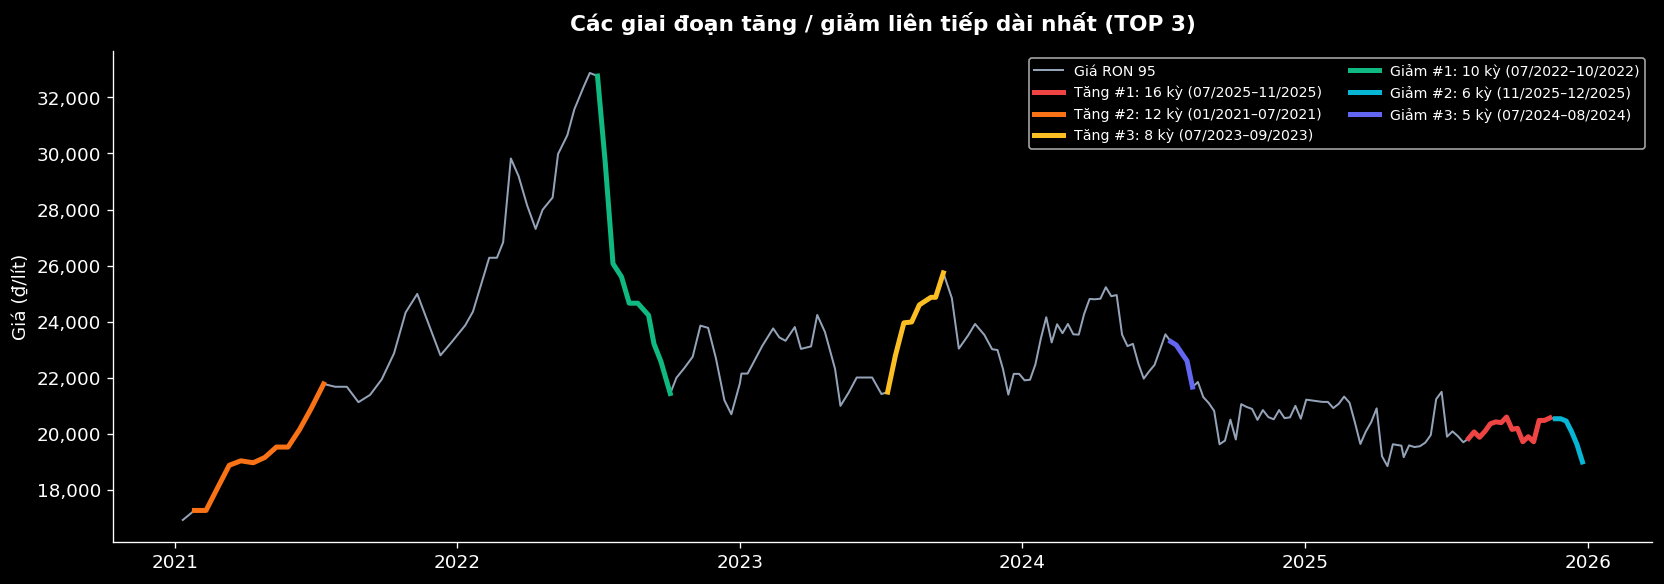


=> Giai đoạn TĂNG dài nhất: 16 kỳ liên tiếp
   (2025-07-31 → 2025-11-13)
   Giá từ 19,840₫ lên 20,570₫

=> Giai đoạn GIẢM dài nhất: 10 kỳ liên tiếp
   (2022-07-01 → 2022-10-03)
   Giá từ 32,760₫ xuống 21,440₫


In [9]:
# ── Trực quan hoá các giai đoạn tăng/giảm dài nhất ──────────────
# Lấy top 3 giai đoạn TĂNG dài nhất
top_tang  = tang_streaks.head(3)
# Lấy top 3 giai đoạn GIẢM dài nhất  
top_giam  = giam_streaks.head(3)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df['Ngay'], df['RON95'], color='#94A3B8', linewidth=1.2, zorder=2, label='Giá RON 95')

colors_tang = ['#EF4444', '#F97316', '#FBBF24']
colors_giam = ['#10B981', '#06B6D4', '#6366F1']

for i, (_, row) in enumerate(top_tang.iterrows()):
    mask = (df['Ngay'] >= row['ngay_bat_dau']) & (df['Ngay'] <= row['ngay_ket_thuc'])
    ax.plot(df.loc[mask,'Ngay'], df.loc[mask,'RON95'],
            color=colors_tang[i], linewidth=3, zorder=4,
            label=f"Tăng #{i+1}: {row['do_dai']} kỳ ({row['ngay_bat_dau'].strftime('%m/%Y')}–{row['ngay_ket_thuc'].strftime('%m/%Y')})")

for i, (_, row) in enumerate(top_giam.iterrows()):
    mask = (df['Ngay'] >= row['ngay_bat_dau']) & (df['Ngay'] <= row['ngay_ket_thuc'])
    ax.plot(df.loc[mask,'Ngay'], df.loc[mask,'RON95'],
            color=colors_giam[i], linewidth=3, zorder=4,
            label=f"Giảm #{i+1}: {row['do_dai']} kỳ ({row['ngay_bat_dau'].strftime('%m/%Y')}–{row['ngay_ket_thuc'].strftime('%m/%Y')})")

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax.set_title('Các giai đoạn tăng / giảm liên tiếp dài nhất (TOP 3)', fontweight='bold', pad=12)
ax.set_ylabel('Giá (₫/lít)')
ax.legend(fontsize=8.5, ncol=2, loc='upper right')
plt.tight_layout()
plt.savefig('bieu_do_streak.png', bbox_inches='tight')
plt.show()

print(f"\n=> Giai đoạn TĂNG dài nhất: {top_tang.iloc[0]['do_dai']} kỳ liên tiếp")
print(f"   ({top_tang.iloc[0]['ngay_bat_dau'].date()} → {top_tang.iloc[0]['ngay_ket_thuc'].date()})")
print(f"   Giá từ {top_tang.iloc[0]['gia_bat_dau']:,}₫ lên {top_tang.iloc[0]['gia_ket_thuc']:,}₫")
print(f"\n=> Giai đoạn GIẢM dài nhất: {top_giam.iloc[0]['do_dai']} kỳ liên tiếp")
print(f"   ({top_giam.iloc[0]['ngay_bat_dau'].date()} → {top_giam.iloc[0]['ngay_ket_thuc'].date()})")
print(f"   Giá từ {top_giam.iloc[0]['gia_bat_dau']:,}₫ xuống {top_giam.iloc[0]['gia_ket_thuc']:,}₫")


## 5. Top 5 tháng giá cao nhất & thấp nhất (Câu hỏi 2 & 4)

**Logic:** Group-by theo `(Năm, Tháng)` → lấy giá max/min trong tháng.  
*(Không dùng `nlargest` trên từng kỳ riêng lẻ vì sẽ lấy trùng cùng một tháng.)*


In [10]:
# Group-by tháng → giá MAX trong tháng (đại diện đỉnh tháng)
monthly_max = (df.groupby(['Nam','Thang'])['RON95']
               .max()
               .reset_index()
               .rename(columns={'RON95':'GiaMax'}))
monthly_max['Thang_Nam_str'] = monthly_max.apply(
    lambda r: f"{int(r['Thang']):02d}/{int(r['Nam'])}", axis=1)

top5_cao = monthly_max.nlargest(5, 'GiaMax')[['Thang_Nam_str','GiaMax']].reset_index(drop=True)
top5_cao.index += 1
top5_cao.columns = ['Tháng/Năm','Giá Max (₫/lít)']

# Group-by tháng → giá MIN trong tháng
monthly_min = (df.groupby(['Nam','Thang'])['RON95']
               .min()
               .reset_index()
               .rename(columns={'RON95':'GiaMin'}))
monthly_min['Thang_Nam_str'] = monthly_min.apply(
    lambda r: f"{int(r['Thang']):02d}/{int(r['Nam'])}", axis=1)

top5_thap = monthly_min.nsmallest(5, 'GiaMin')[['Thang_Nam_str','GiaMin']].reset_index(drop=True)
top5_thap.index += 1
top5_thap.columns = ['Tháng/Năm','Giá Min (₫/lít)']

print("=== TOP 5 THÁNG GIÁ CAO NHẤT ===")
print(top5_cao.to_string())
print()
print("=== TOP 5 THÁNG GIÁ THẤP NHẤT ===")
print(top5_thap.to_string())


=== TOP 5 THÁNG GIÁ CAO NHẤT ===
  Tháng/Năm  Giá Max (₫/lít)
1   06/2022            32870
2   07/2022            32760
3   05/2022            30650
4   03/2022            29820
5   04/2022            28150

=== TOP 5 THÁNG GIÁ THẤP NHẤT ===
  Tháng/Năm  Giá Min (₫/lít)
1   01/2021            16930
2   02/2021            17270
3   04/2025            18850
4   03/2021            18880
5   04/2021            18970


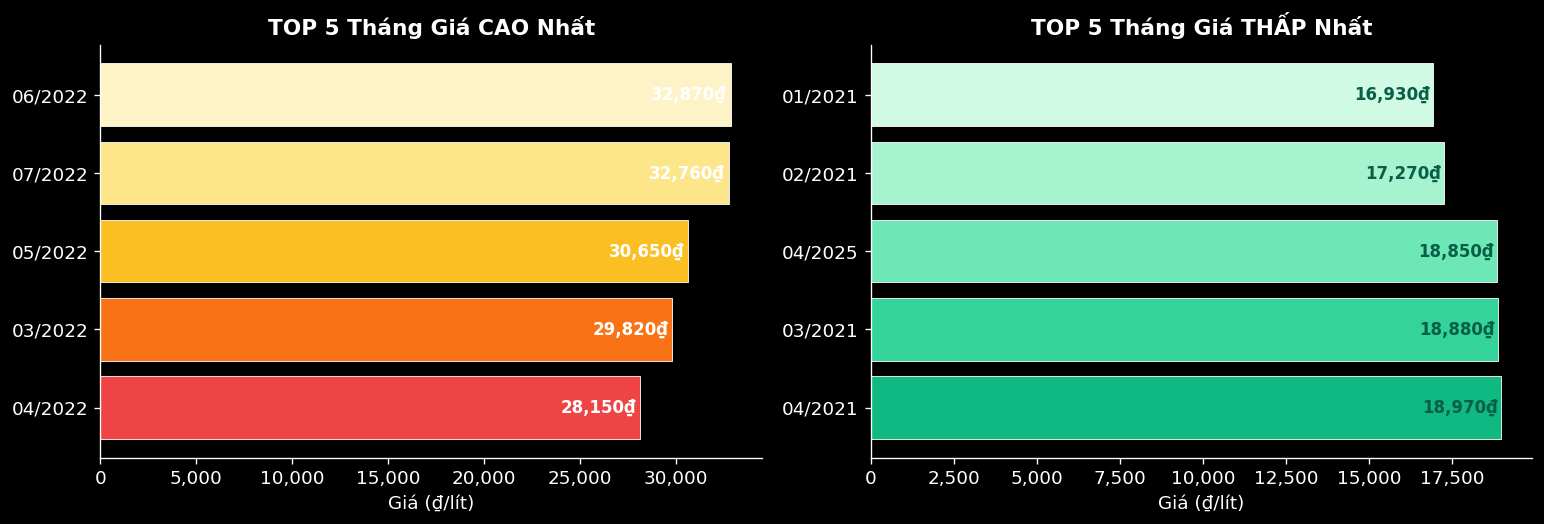

In [11]:
# Biểu đồ so sánh Top 5 cao & thấp
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# Top 5 cao nhất
bars1 = ax1.barh(top5_cao['Tháng/Năm'][::-1], top5_cao['Giá Max (₫/lít)'][::-1],
                 color=['#EF4444','#F97316','#FBBF24','#FDE68A','#FEF3C7'],
                 edgecolor='white', linewidth=0.5)
for bar, val in zip(bars1, top5_cao['Giá Max (₫/lít)'][::-1]):
    ax1.text(bar.get_width() - 200, bar.get_y() + bar.get_height()/2,
             f'{val:,}₫', va='center', ha='right', fontsize=10, fontweight='bold', color='white')
ax1.set_title('TOP 5 Tháng Giá CAO Nhất', fontweight='bold')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax1.set_xlabel('Giá (₫/lít)')

# Top 5 thấp nhất
bars2 = ax2.barh(top5_thap['Tháng/Năm'][::-1], top5_thap['Giá Min (₫/lít)'][::-1],
                 color=['#10B981','#34D399','#6EE7B7','#A7F3D0','#D1FAE5'],
                 edgecolor='white', linewidth=0.5)
for bar, val in zip(bars2, top5_thap['Giá Min (₫/lít)'][::-1]):
    ax2.text(bar.get_width() - 100, bar.get_y() + bar.get_height()/2,
             f'{val:,}₫', va='center', ha='right', fontsize=10, fontweight='bold', color='#065F46')
ax2.set_title('TOP 5 Tháng Giá THẤP Nhất', fontweight='bold')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax2.set_xlabel('Giá (₫/lít)')

plt.tight_layout()
plt.savefig('bieu_do_top5.png', bbox_inches='tight')
plt.show()


## 6. Giá trung bình theo năm (Câu hỏi 3)

=== GIÁ TRUNG BÌNH THEO NĂM ===
 Năm  TB (₫)  Max (₫)  Min (₫)  Số kỳ
2021   20730    24990    16930     24
2022   26181    32870    20700     34
2023   23027    25740    21000     38
2024   22353    25230    19630     52
2025   20193    21500    18850     50

=> Năm có giá TB cao nhất: 2022 (26,181₫/lít)


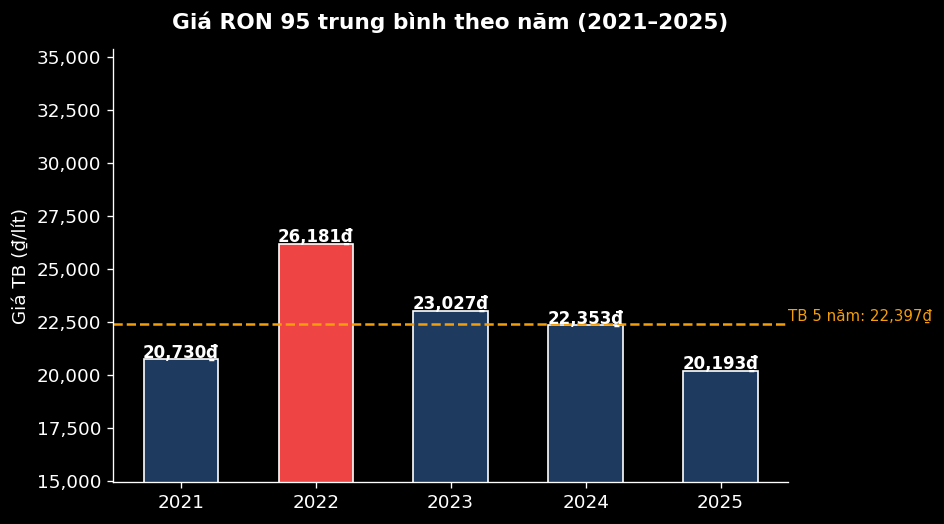

In [12]:
gia_tb_nam = (df.groupby('Nam')['RON95']
              .agg(['mean','max','min','count'])
              .round(0).astype(int)
              .reset_index())
gia_tb_nam.columns = ['Năm','TB (₫)','Max (₫)','Min (₫)','Số kỳ']

nam_cao_nhat = gia_tb_nam.loc[gia_tb_nam['TB (₫)'].idxmax(), 'Năm']
tb_cao_nhat  = gia_tb_nam['TB (₫)'].max()

print("=== GIÁ TRUNG BÌNH THEO NĂM ===")
print(gia_tb_nam.to_string(index=False))
print()
print(f"=> Năm có giá TB cao nhất: {nam_cao_nhat} ({tb_cao_nhat:,}₫/lít)")

# Biểu đồ
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ['#EF4444' if n == nam_cao_nhat else '#1E3A5F' for n in gia_tb_nam['Năm']]
bars = ax.bar(gia_tb_nam['Năm'].astype(str), gia_tb_nam['TB (₫)'],
              color=colors, width=0.55, edgecolor='white')

for bar, val in zip(bars, gia_tb_nam['TB (₫)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{val:,}₫', ha='center', fontsize=10, fontweight='bold')

# Đường mean toàn kỳ
grand_mean = int(df['RON95'].mean())
ax.axhline(grand_mean, color='#F59E0B', linestyle='--', linewidth=1.5)
ax.text(ax.get_xlim()[1] if ax.get_xlim()[1] != 1.0 else 4.6,
        grand_mean + 150, f'TB 5 năm: {grand_mean:,}₫', fontsize=9, color='#F59E0B')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax.set_title('Giá RON 95 trung bình theo năm (2021–2025)', fontweight='bold', pad=12)
ax.set_ylabel('Giá TB (₫/lít)')
ax.set_ylim(df['RON95'].min() - 2000, df['RON95'].max() + 2500)
plt.tight_layout()
plt.savefig('bieu_do_tb_nam.png', bbox_inches='tight')
plt.show()


## 7. Phân phối giá theo từng năm (Câu hỏi 5)

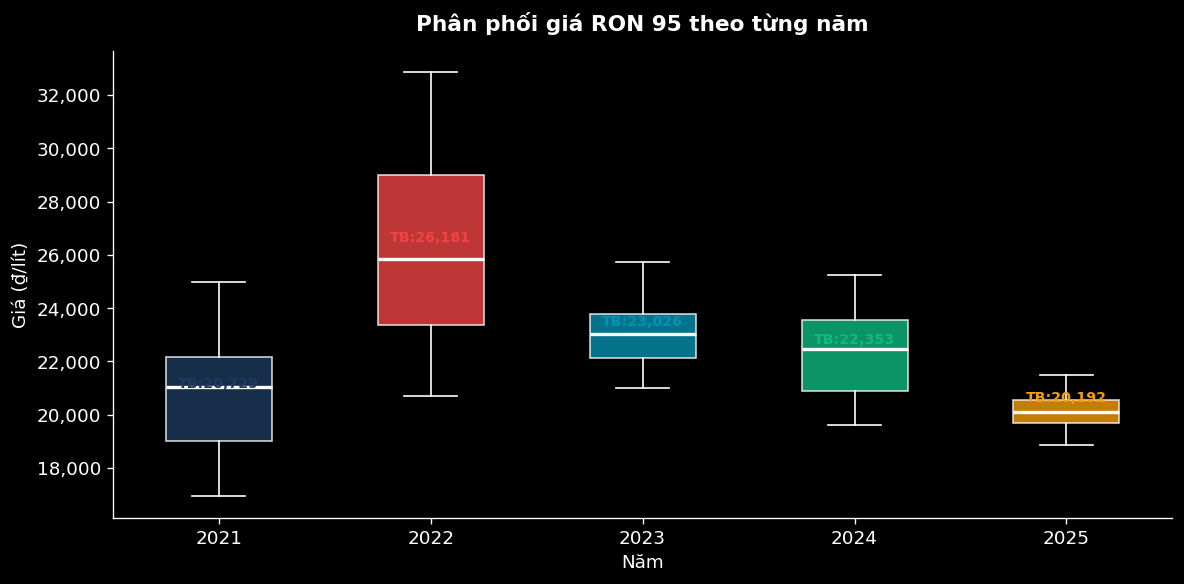

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))

data_by_year = [df[df['Nam'] == y]['RON95'].values for y in sorted(df['Nam'].unique())]
bp = ax.boxplot(data_by_year, labels=[str(y) for y in sorted(df['Nam'].unique())],
                patch_artist=True, medianprops=dict(color='white', linewidth=2))

box_colors = ['#1E3A5F','#EF4444','#0891B2','#10B981','#F59E0B']
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax.set_title('Phân phối giá RON 95 theo từng năm', fontweight='bold', pad=12)
ax.set_ylabel('Giá (₫/lít)')
ax.set_xlabel('Năm')

# Ghi giá TB mỗi năm
for i, (y, color) in enumerate(zip(sorted(df['Nam'].unique()), box_colors)):
    tb = int(df[df['Nam']==y]['RON95'].mean())
    ax.text(i+1, tb + 300, f'TB:{tb:,}', ha='center', fontsize=8.5, color=color, fontweight='bold')

plt.tight_layout()
plt.savefig('bieu_do_boxplot.png', bbox_inches='tight')
plt.show()


## 8. Tổng hợp kết quả (số liệu thực từ dữ liệu)

In [14]:
print("=" * 60)
print("  KẾT QUẢ PHÂN TÍCH GIÁ XĂNG RON 95 | 2021–2025")
print("=" * 60)

idx_max = df['RON95'].idxmax()
idx_min = df['RON95'].idxmin()

print(f"\n[C1] Giai đoạn TĂNG liên tiếp dài nhất:")
r = top_tang.iloc[0]
print(f"     {r['do_dai']} kỳ | {r['ngay_bat_dau'].strftime('%d/%m/%Y')} → {r['ngay_ket_thuc'].strftime('%d/%m/%Y')}")
print(f"     Giá: {r['gia_bat_dau']:,}₫ → {r['gia_ket_thuc']:,}₫  (+{r['gia_ket_thuc']-r['gia_bat_dau']:,}₫)")

print(f"\n[C1] Giai đoạn GIẢM liên tiếp dài nhất:")
r2 = top_giam.iloc[0]
print(f"     {r2['do_dai']} kỳ | {r2['ngay_bat_dau'].strftime('%d/%m/%Y')} → {r2['ngay_ket_thuc'].strftime('%d/%m/%Y')}")
print(f"     Giá: {r2['gia_bat_dau']:,}₫ → {r2['gia_ket_thuc']:,}₫  ({r2['gia_ket_thuc']-r2['gia_bat_dau']:,}₫)")

print(f"\n[C2] TOP 3 tháng giá CAO nhất:")
for i, row in top5_cao.head(3).iterrows():
    print(f"     #{i} {row['Tháng/Năm']:>8s}  →  {row['Giá Max (₫/lít)']:,}₫/lít")

print(f"\n[C3] Năm có giá TB CAO nhất: {nam_cao_nhat}  ({tb_cao_nhat:,}₫/lít)")

print(f"\n[C4] TOP 3 tháng giá THẤP nhất:")
for i, row in top5_thap.head(3).iterrows():
    print(f"     #{i} {row['Tháng/Năm']:>8s}  →  {row['Giá Min (₫/lít)']:,}₫/lít")

print(f"\n[C5] Xu hướng theo năm:")
for _, row in gia_tb_nam.iterrows():
    marker = ' ◄ CAO NHẤT' if row['Năm'] == nam_cao_nhat else ''
    print(f"     {row['Năm']}: TB {row['TB (₫)']:,}₫  |  Max {row['Max (₫)']:,}₫  |  Min {row['Min (₫)']:,}₫{marker}")

print()


  KẾT QUẢ PHÂN TÍCH GIÁ XĂNG RON 95 | 2021–2025

[C1] Giai đoạn TĂNG liên tiếp dài nhất:
     16 kỳ | 31/07/2025 → 13/11/2025
     Giá: 19,840₫ → 20,570₫  (+730₫)

[C1] Giai đoạn GIẢM liên tiếp dài nhất:
     10 kỳ | 01/07/2022 → 03/10/2022
     Giá: 32,760₫ → 21,440₫  (-11,320₫)

[C2] TOP 3 tháng giá CAO nhất:
     #1  06/2022  →  32,870₫/lít
     #2  07/2022  →  32,760₫/lít
     #3  05/2022  →  30,650₫/lít

[C3] Năm có giá TB CAO nhất: 2022  (26,181₫/lít)

[C4] TOP 3 tháng giá THẤP nhất:
     #1  01/2021  →  16,930₫/lít
     #2  02/2021  →  17,270₫/lít
     #3  04/2025  →  18,850₫/lít

[C5] Xu hướng theo năm:
     2021: TB 20,730₫  |  Max 24,990₫  |  Min 16,930₫
     2022: TB 26,181₫  |  Max 32,870₫  |  Min 20,700₫ ◄ CAO NHẤT
     2023: TB 23,027₫  |  Max 25,740₫  |  Min 21,000₫
     2024: TB 22,353₫  |  Max 25,230₫  |  Min 19,630₫
     2025: TB 20,193₫  |  Max 21,500₫  |  Min 18,850₫

